In [10]:
# ============================================
# TEMPLATE PREPROCESSING - REUSABLE
# ============================================

# Data manipulation and numerical computing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (classification_report, 
                             roc_auc_score, 
                             ConfusionMatrixDisplay)

# Decision Tree and Random Forest models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------
# 1. LOAD DATA
# --------------------------------------------
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')

# --------------------------------------------
# 2. CLEANING
# --------------------------------------------
# TotalCharges has hidden spaces ' ' → convert to numeric
# errors='coerce' turns invalid values into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with NaN (only 11 rows affected)
df.dropna(inplace=True)

# Drop customer ID → not a predictive feature
df.drop(columns=['customerID'], inplace=True)

# Encode target variable as binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --------------------------------------------
# 3. DEFINE FEATURES
# --------------------------------------------
# Continuous columns → will be scaled
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Categorical columns → will be one-hot encoded
# Automatically selects all columns except continuous and target
categorical_cols = [col for col in df.columns 
                    if col not in continuous_cols + ['Churn']]

# --------------------------------------------
# 4. ONE-HOT ENCODING
# --------------------------------------------
# drop_first=True avoids the dummy variable trap
# e.g. Gender: Male/Female → only Female column kept
df_encoded = pd.get_dummies(df, 
                             columns=categorical_cols, 
                             drop_first=True)

# --------------------------------------------
# 5. SPLIT X AND y
# --------------------------------------------
# X → all features (everything except target)
# y → target variable (Churn)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# --------------------------------------------
# 6. TRAIN/TEST SPLIT
# --------------------------------------------
# test_size=0.2 → 80% train, 20% test
# stratify=y → preserves class balance in both sets
# random_state=42 → reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# 7. SCALING (continuous columns only)
# --------------------------------------------
# fit_transform on train → learns mean and std from train only
# transform on test → applies same scaling (no data leakage)
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("✅ Preprocessing complete")
print(f"   Train set: {X_train.shape}")
print(f"   Test set:  {X_test.shape}")
print(f"   Churn rate: {y.mean():.2%}")

✅ Preprocessing complete
   Train set: (5625, 30)
   Test set:  (1407, 30)
   Churn rate: 26.58%


In [11]:
#model
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

#train the model
dt.fit(X_train, y_train)

#predictions
y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)[:,1]

#evaluation
print("=== Decision Tree ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC:{roc_auc_score(y_test, y_pred_proba):.3f}")

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

AUC-ROC:0.820


In [12]:
#randomForest
rf = RandomForestClassifier(
    n_estimators= 100,
    max_depth= 4,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC:{roc_auc_score(y_test, y_pred_proba):.3f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1033
           1       0.67      0.40      0.50       374

    accuracy                           0.79      1407
   macro avg       0.74      0.66      0.68      1407
weighted avg       0.77      0.79      0.77      1407

AUC-ROC:0.832


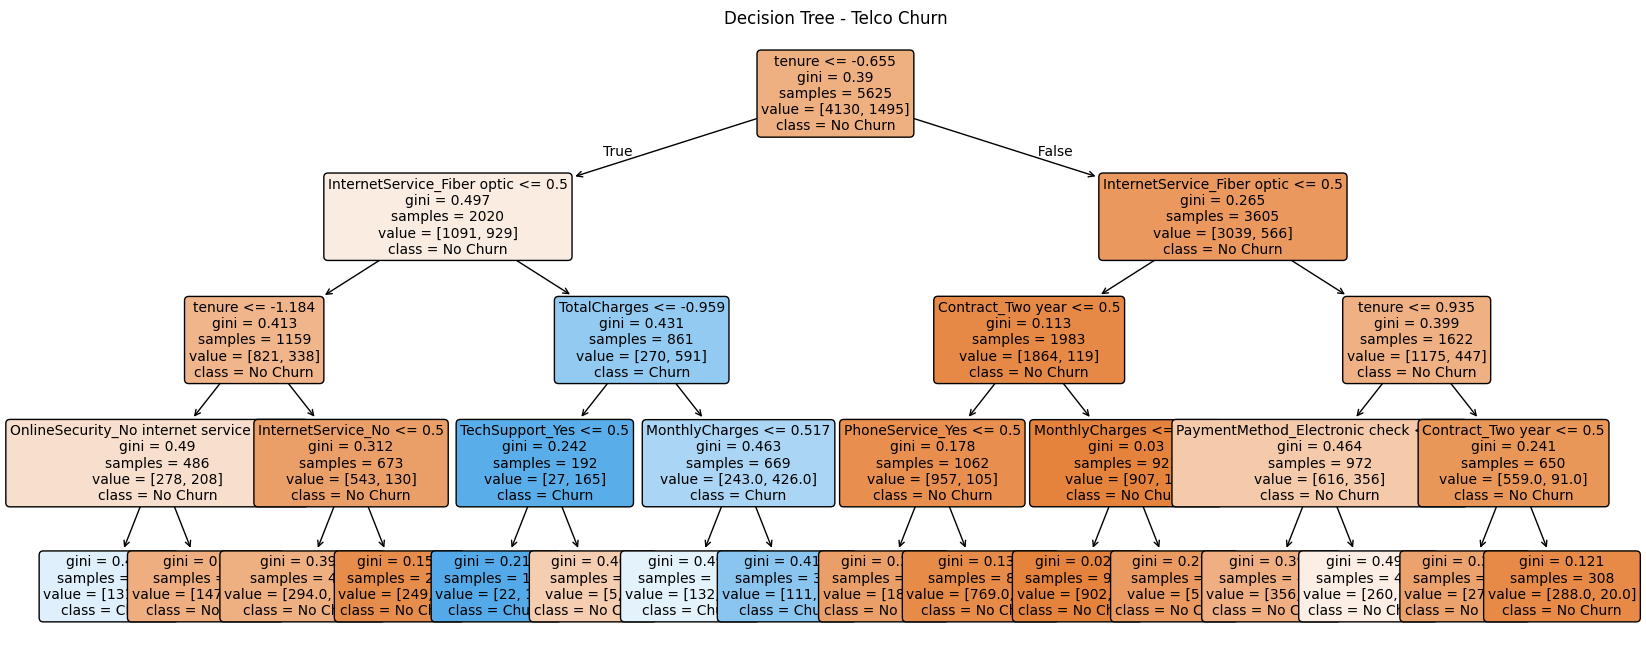

In [13]:
plt.figure(figsize=(20, 8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['No Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree - Telco Churn")
plt.savefig("decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()

                                 feature  importance
0                                 tenure    0.230032
2                           TotalCharges    0.116134
10           InternetService_Fiber optic    0.108604
28        PaymentMethod_Electronic check    0.090195
25                     Contract_Two year    0.088160
1                         MonthlyCharges    0.049433
16  DeviceProtection_No internet service    0.036042
13                    OnlineSecurity_Yes    0.035837
12    OnlineSecurity_No internet service    0.032553
24                     Contract_One year    0.031236


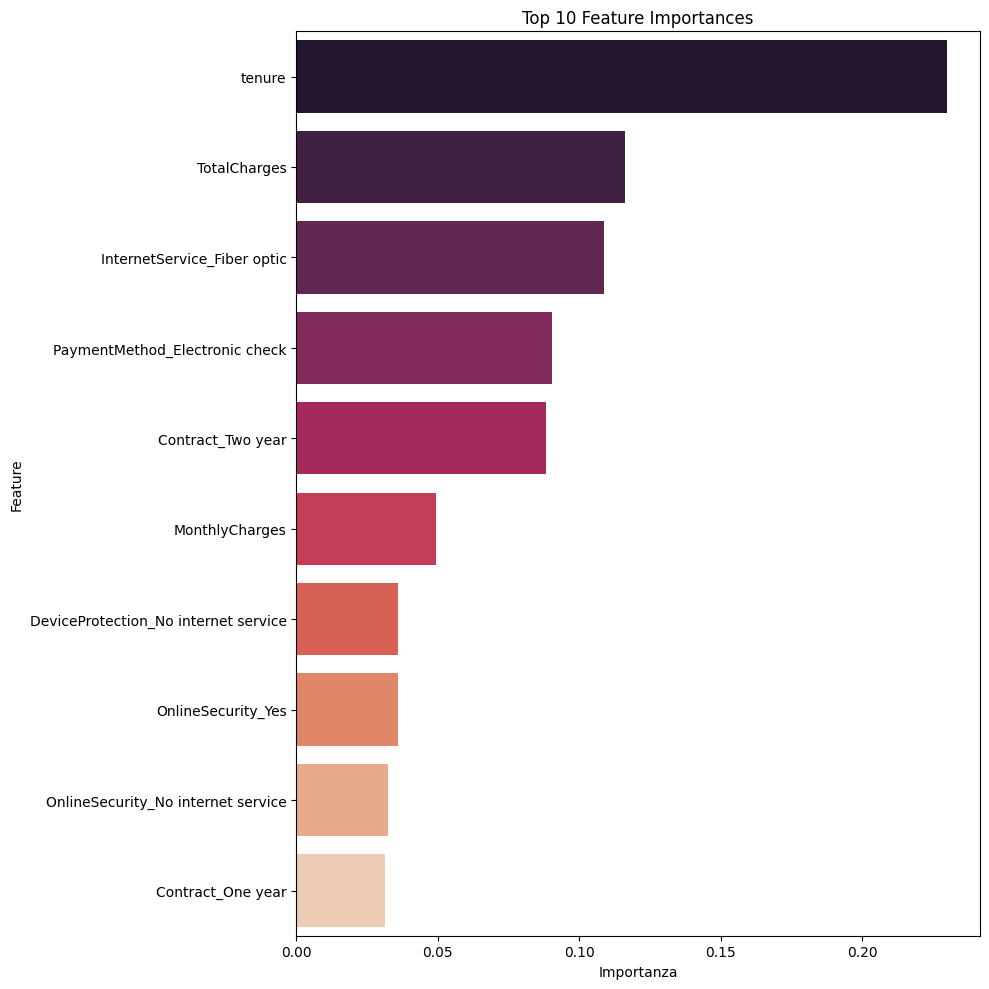

In [14]:
#dataframe
df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending = False).head(10)
print(df)

#barplot
plt.figure(figsize=(10, 10))
sns.barplot(data = df,
            x='importance',
            y='feature', 
            hue='feature',
            palette='rocket')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importanza')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# 📊 Osservazioni — Decision Tree & Random Forest su Telco Churn

---

## 1. Performance dei modelli

| Metrica | Decision Tree | Random Forest |
|---|---|---|
| Accuracy | 0.78 | 0.79 |
| AUC-ROC | 0.820 | 0.832 |
| Churn Recall | 0.50 | 0.40 |
| Churn Precision | 0.61 | 0.67 |

---

## 2. Scelta del modello in contesto business

Il **Decision Tree** è preferibile alla Random Forest nonostante un AUC-ROC leggermente inferiore.  
Il motivo è il **Recall più alto sulla classe Churn** (0.50 vs 0.40): in un contesto di retention clienti, un falso negativo (cliente a rischio non identificato) costa molto di più di un falso positivo (cliente contattato inutilmente).  
> Acquisire un nuovo cliente costa **5-7x** più che trattenerne uno esistente.

---

## 3. Feature Importance — Top 10

| Rank | Feature | Importance |
|---|---|---|
| 1 | tenure | 0.230 |
| 2 | TotalCharges | 0.116 |
| 3 | InternetService_Fiber optic | 0.109 |
| 4 | PaymentMethod_Electronic check | 0.090 |
| 5 | Contract_Two year | 0.088 |
| 6 | MonthlyCharges | 0.049 |
| 7 | DeviceProtection_No internet service | 0.036 |
| 8 | OnlineSecurity_Yes | 0.036 |
| 9 | OnlineSecurity_No internet service | 0.033 |
| 10 | Contract_One year | 0.031 |

---

## 4. Interpretazione business delle feature principali

- **`tenure`** è il predittore dominante — i clienti con bassa anzianità aziendale sono i più a rischio churn. Il periodo critico è nei primi mesi del rapporto con l'azienda.

- **`InternetService_Fiber optic`** e **`PaymentMethod_Electronic check`** suggeriscono profili di clienti più volatili — probabilmente tech-savvy con alta propensione al confronto tra competitor.

- **`Contract_Two year`** ha importanza negativa implicita — i clienti con contratti lunghi hanno meno probabilità di abbandonare (effetto lock-in).

---

## 5. ⚠️ Problema di multicollinearità — tenure e TotalCharges

`tenure` e `TotalCharges` sono fortemente correlate: all'aumentare dell'anzianità del cliente aumenta necessariamente il totale speso.  
Questa correlazione rischia di **sovrastimare l'effetto combinato** delle due variabili, disperdendo l'importanza reale su entrambe invece di concentrarla sulla causa principale.

**Possibili soluzioni:**
- Rimuovere `TotalCharges` e riaddestrare il modello
- Applicare PCA per creare componenti non correlate
- Verificare il grado di correlazione:

```python
df[['tenure', 'TotalCharges']].corr()
```

---

## 6. Limitazioni del modello

- **Dataset sbilanciato**: ~26% churn vs ~74% non churn — il recall sulla classe minoritaria resta basso
- **max_depth=4** è conservativo — ottimizzabile con cross-validation
- **Feature importance RF** non mostra la direzione dell'effetto (positivo/negativo) — per quello serve la regressione logistica con odds ratio

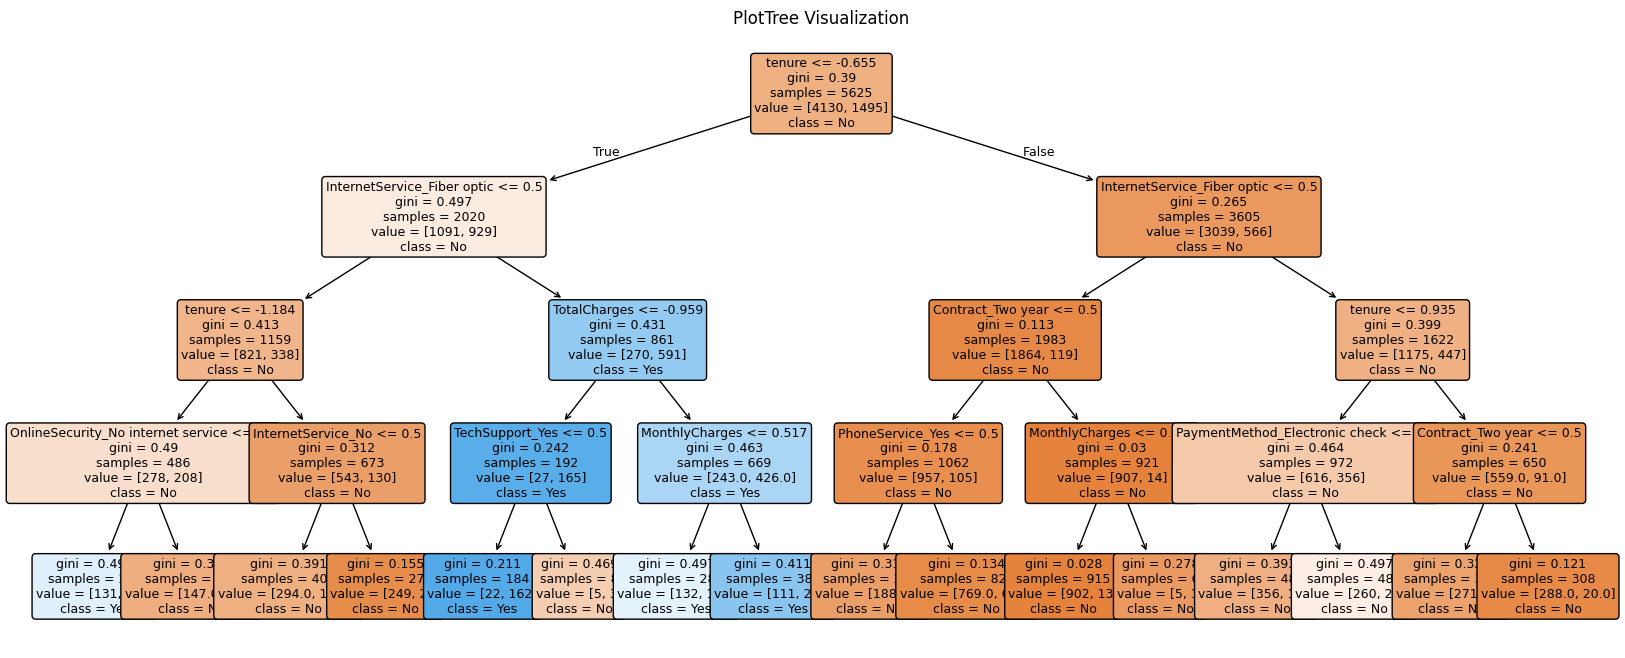

In [15]:
#plottree visualization
plt.figure(figsize=(20,8))
plot_tree(dt,
          feature_names= X.columns,
          class_names=['No', 'Yes'],
          filled = True,
          rounded=True, 
          fontsize=9)
plt.title('PlotTree Visualization')
plt.savefig('decision_tree.png',
            dpi=150,
            bbox_inches='tight')             
plt.show()